In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

## Estimacion Basica (Vainilla)

#### cargar datos

In [23]:
data = pd.read_csv("data/casas-california.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### visualizar casa de california

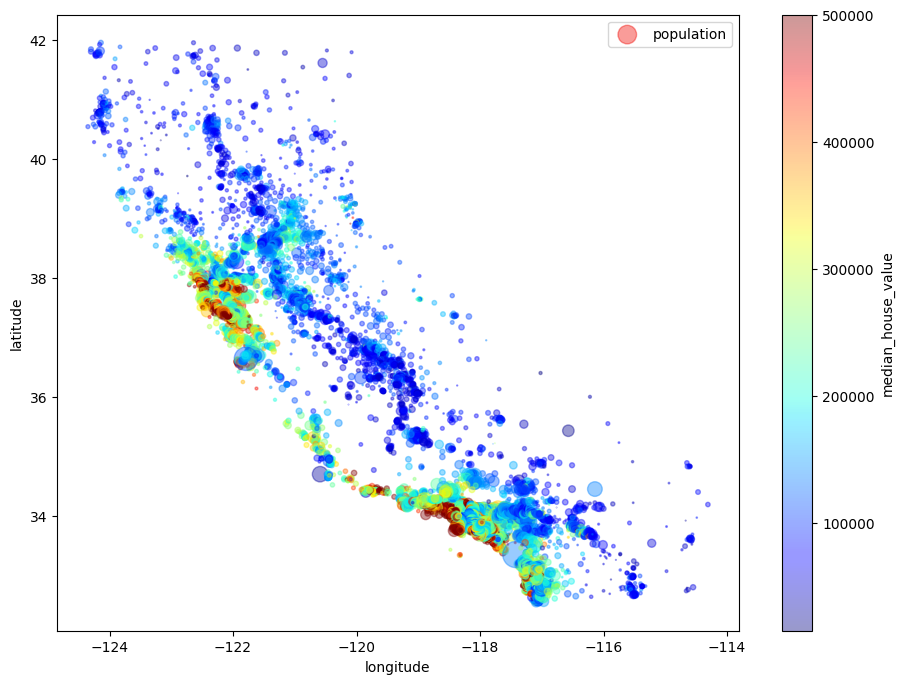

In [24]:
data.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
          s=data["population"] / 100, label="population", figsize=(11,8),
          c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True) 
plt.legend()
plt.show()

#### correlaciones

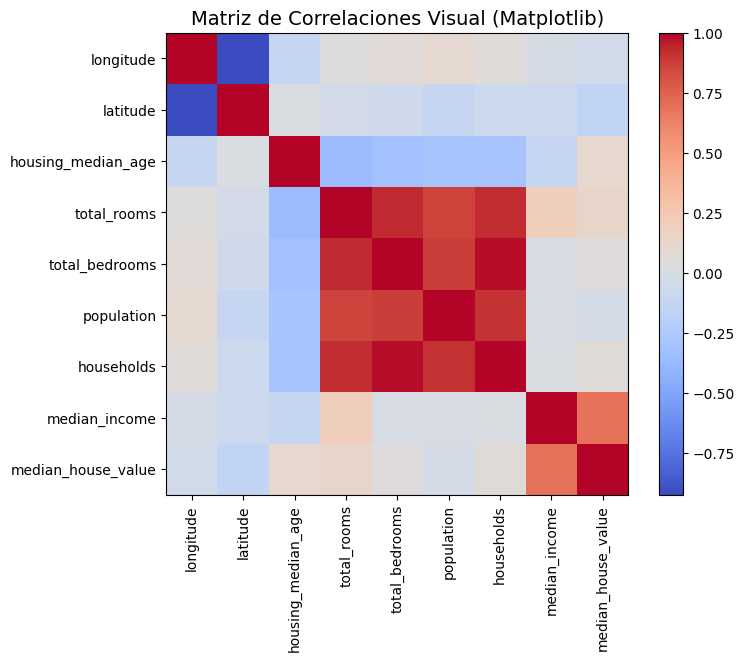

In [25]:
### EJERCICIO: (1pt) 
# utilize matplotlib para desplegar la matriz de correlaciones

data_numeric = data.drop('ocean_proximity', axis=1, errors='ignore')
corr = data_numeric.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
# Colocamos las etiquetas en los ejes
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlaciones Visual (Matplotlib)", fontsize=14)
plt.show()

In [35]:
#Matriz de correlación
#Otra solución sería hacer una agrupación seleccionando solamente los datos numéricos
#other_variables = data[["longitude", "latitude","housing_median_age",'total_bedrooms','total_rooms', 'population', 'households', 'median_income', 'median_house_value']]
#for c in data.columns:
#    data[c] = pd.to_numeric(data[c], errors = 'coerce')
corr = data.corr()
print(corr)


                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   
ocean_proximity     -0.289779  0.200974            0.112468    -0.015693   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude 

In [36]:
### EJERCICIO: (1pt) 
# despliegue las correlaciones de la variable median_house_value
corr_target = corr['median_house_value'].sort_values(ascending=False)
print("Correlaciones con respecto a median_house_value:\n", corr_target)


Correlaciones con respecto a median_house_value:
 median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
ocean_proximity       0.081750
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


#### limpieza de datos

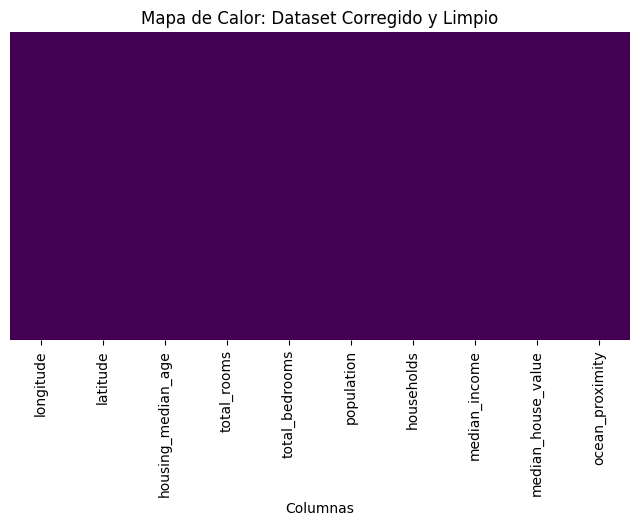

In [37]:
### EJERCICIO: (1pt)
# utilize seaborn para revisar de que no hay valores en blanco. despliegue el grafico de seaborn.
data = pd.read_csv("data/casas-california.csv")

# Rellenamos los nulos de 'total_bedrooms' con su mediana
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

# Graficamos con Seaborn 
plt.figure(figsize=(8, 4))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa de Calor: Dataset Corregido y Limpio")
plt.xlabel("Columnas")
plt.show()

C:\Users\doria\AppData\Local\Temp\ipykernel_6116\3575051583.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\doria\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


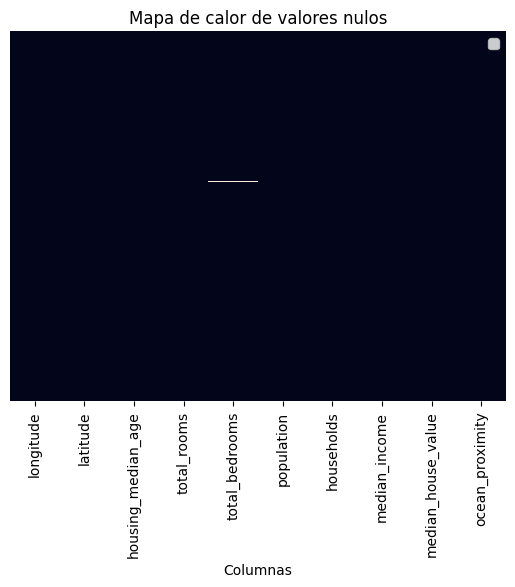

In [38]:
data = pd.read_csv("data/casas-california.csv")
sns.heatmap(data.isnull(), cbar = False, yticklabels = False)
plt.title("Mapa de calor de valores nulos")
plt.xlabel("Columnas")
plt.legend()
plt.show()

In [39]:
### EJERCICIO: (1pt)
# Revise los tipos de las columnas y verifique que cada uno esta definido correctamente 
# (ejemplo, la variable OCEAN_PROXIMITY debe ser categorica)

enc = OrdinalEncoder()
data[["ocean_proximity"]] = enc.fit_transform(data[["ocean_proximity"]].astype(str))

# OCEAN_PROXIMITY lo definimos como tipo 'category' en Pandas
data["ocean_proximity"] = data["ocean_proximity"].astype('category')

print("\nVerificación de tipos de columnas:")
print(data.dtypes)


Verificación de tipos de columnas:
longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object


#### test & training set

In [40]:
### EJERCICIO: (1pt) 
# separe el dataset train:80%, test:70%, random_state=42 
# donde y = median_house_value
y = data["median_house_value"]
X = data.drop("median_house_value", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#### regresion lineal multiple

In [41]:
### EJERCICIO: (1pt)
# estime el modelo de regresion lineal utilizando Sklearn.
# imprima los coeficientes
model_vanilla = LinearRegression()
model_vanilla.fit(X_train, y_train)

print("\n--- MODELO VANILLA (SKLEARN) ---")
print("Intercepto (b0):", model_vanilla.intercept_)
print("Coeficientes (Betas):", model_vanilla.coef_)



--- MODELO VANILLA (SKLEARN) ---
Intercepto (b0): -3594630.7600683277
Coeficientes (Betas): [-4.28077658e+04 -4.25657762e+04  1.18426973e+03 -8.13638808e+00
  1.16392023e+02 -3.85957093e+01  4.62029610e+01  4.05118332e+04
 -3.18827157e+02]


In [42]:
### EJERCICIO: (1pt)
# utilize statsmodels para estimar las estadisticas del modelo actual.
# estime el MSE del train/test

y_pred_train = model_vanilla.predict(X_train)
y_pred_test = model_vanilla.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE Entrenamiento: {mse_train:,.2f}")
print(f"MSE Prueba (Test): {mse_test:,.2f}")
print(f"RMSE Prueba (Raíz del error): {np.sqrt(mse_test):,.2f}")

# Estadísticas en Statsmodels
X_train_sm = sm.add_constant(X_train)
model_ols = sm.OLS(y_train, X_train_sm).fit()
print(model_ols.summary())


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Estimacion Avanzada - Feature Engineering

En este momento, ud acaba de realizar la estimación del modelo más básico, sin aplicar transformaciones, ni escalamientos a las variables. 

**Aqui es donde se pone bonito...**

En esta sección debe estudiar las variables, sus distribuciones, para identificar qué tipo de cosas se pueden realizar para mejorar el modelo. Vuelva a calcular las estadísticas del modelo (antes y después) para que tenga un punto de referencia.

Algunas recomendaciones:
- Trate de comprender el rol de la variable en la prediccion. Tiene sentido?
- Algunos modelos trabajan mejor con menos variables. (aqui puede agregar o remover variables)
- Aplique transformaciones para "normalizar" variables (que tengan una distribucion quasi-normal)
- considere crear nuevas variables de ser necesario: por ejemplo bedrooms_per_room = data["total_bedrooms"] / data["total_rooms"]

In [18]:
### EJERCICIO: (1pt)
# Aplique Escalamiento y Transformaciones

data2 = data.loc[:, ['median_income', 'longitude', 'latitude', 'median_house_value', 'housing_median_age']]
data2 = data2.apply(pd.to_numeric, errors='coerce')

# 2. Convertimos el ocean_proximity original a texto limpio y creamos las dummies como ENTEROS (0 y 1)
data.ocean_proximity = data.ocean_proximity.astype(str)
dummies = pd.get_dummies(data.ocean_proximity, prefix="OP", dtype=int)
data2 = data2.join(dummies)

# 3. Forzamos a numéricas las variables que usaremos para las divisiones
total_b = pd.to_numeric(data["total_bedrooms"], errors='coerce')
total_r = pd.to_numeric(data["total_rooms"], errors='coerce')
househ = pd.to_numeric(data["households"], errors='coerce')
popula = pd.to_numeric(data["population"], errors='coerce')

# 4. Creamos las nuevas variables numéricas
data2["households_per_population"] = househ / popula
data2["bedrooms_per_total_rooms"] = total_b / total_r

# 5. PASO DE SEGURIDAD PARA STATSMODELS: Rellenamos cualquier NaN residual con la mediana
data2 = data2.fillna(data2.median())

AttributeError: 'DataFrame' object has no attribute 'ocean_proximity'

In [18]:
### EJERCICIO: (1pt)
# Estime nuevamente el modelo de regresion lineal

y = data2.median_house_value
X = data2.loc[:, data2.columns != 'median_house_value']

# Forzamos a X e y a ser flotantes puros de numpy (Esto elimina los tipos 'object' para siempre)
X = X.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Entrenamos con el conjunto de entrenamiento (X_train)
model = LinearRegression().fit(X_train, y_train)

print("Coeficientes:")
print("b", 0, ":", "%.2f" % model.intercept_)
for i, b in zip(np.arange(1, len(model.coef_) + 1), model.coef_):
    print("b", i, ":", "%.2f" % b)



Coeficientes:
b 0 : -2390510.71
b 1 : 41634.07
b 2 : -26985.79
b 3 : -26305.47
b 4 : 903.71
b 5 : -16359.20
b 6 : -50722.90
b 7 : 111912.08
b 8 : -25549.14
b 9 : -19280.83
b 10 : 303425.20
b 11 : 182683.33


In [19]:
### EJERCICIO: (1pt)
# Calcule nuevamente las estadisticas para determinar si hay mejoras sobre el modelo.
# estime el MSE del train/test

y_prima_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_prima_train)

y_prima_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_prima_test)

print("\nMSE Train:", np.sqrt(mse_train))
print(" MSE Test:", np.sqrt(mse_test))

print("\n" * 2)

# Ahora statsmodels recibirá floats perfectos y va a correr sin pestañear
model_ols = sm.OLS(y_train, sm.add_constant(X_train))
pred = model_ols.fit()
print(pred.summary())


MSE Train: 65608.41539426312
 MSE Test: 68233.54420636174



                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     3474.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:40:17   Log-Likelihood:            -2.0657e+05
No. Observations:               16512   AIC:                         4.132e+05
Df Residuals:                   16501   BIC:                         4.133e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(regressor, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
scores = np.sqrt(-scores)

scores.mean()

np.float64(68649.96534036435)